In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import Sequential
from keras.optimizers import Adam
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import pickle
import warnings

In [4]:
pd.set_option("display.max_columns", None)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
tensorflow.random.set_seed(42)
np.random.seed(42)

# Exploration Data

In [50]:
df = pd.read_csv('housing.csv', sep=',')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [51]:
df.shape

(20640, 10)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [53]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [54]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [55]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

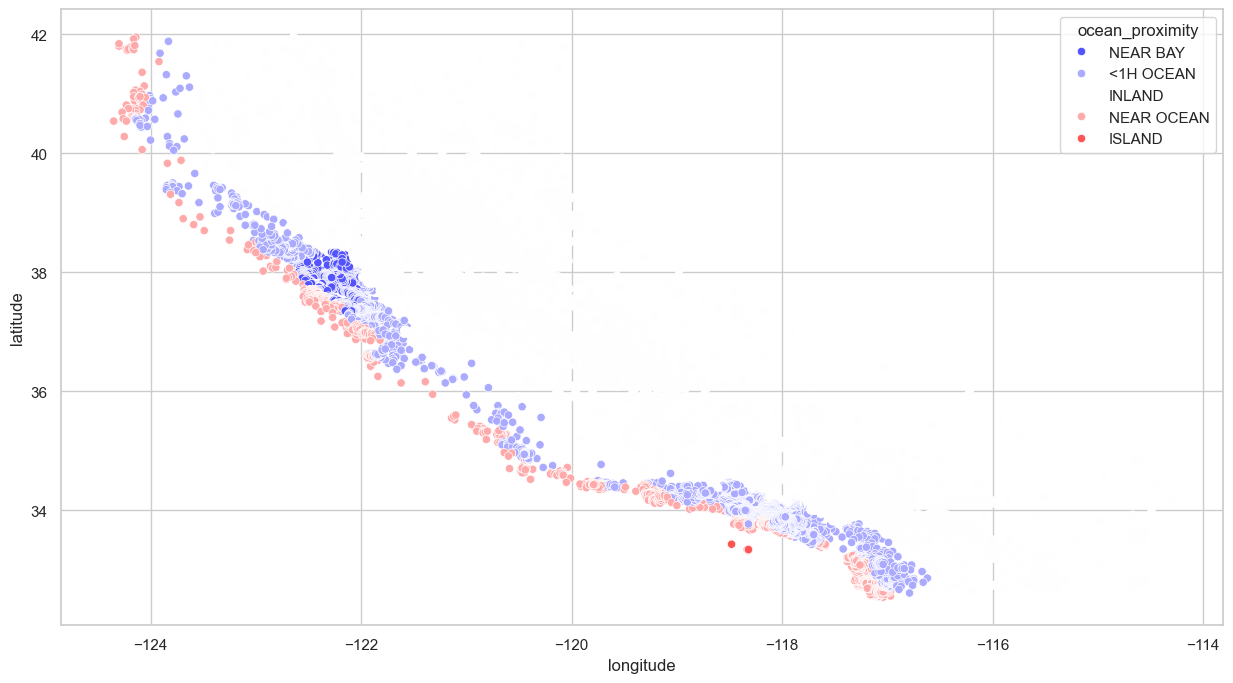

In [56]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='longitude', y='latitude', data=df, hue='ocean_proximity', palette='bwr')
plt.show()

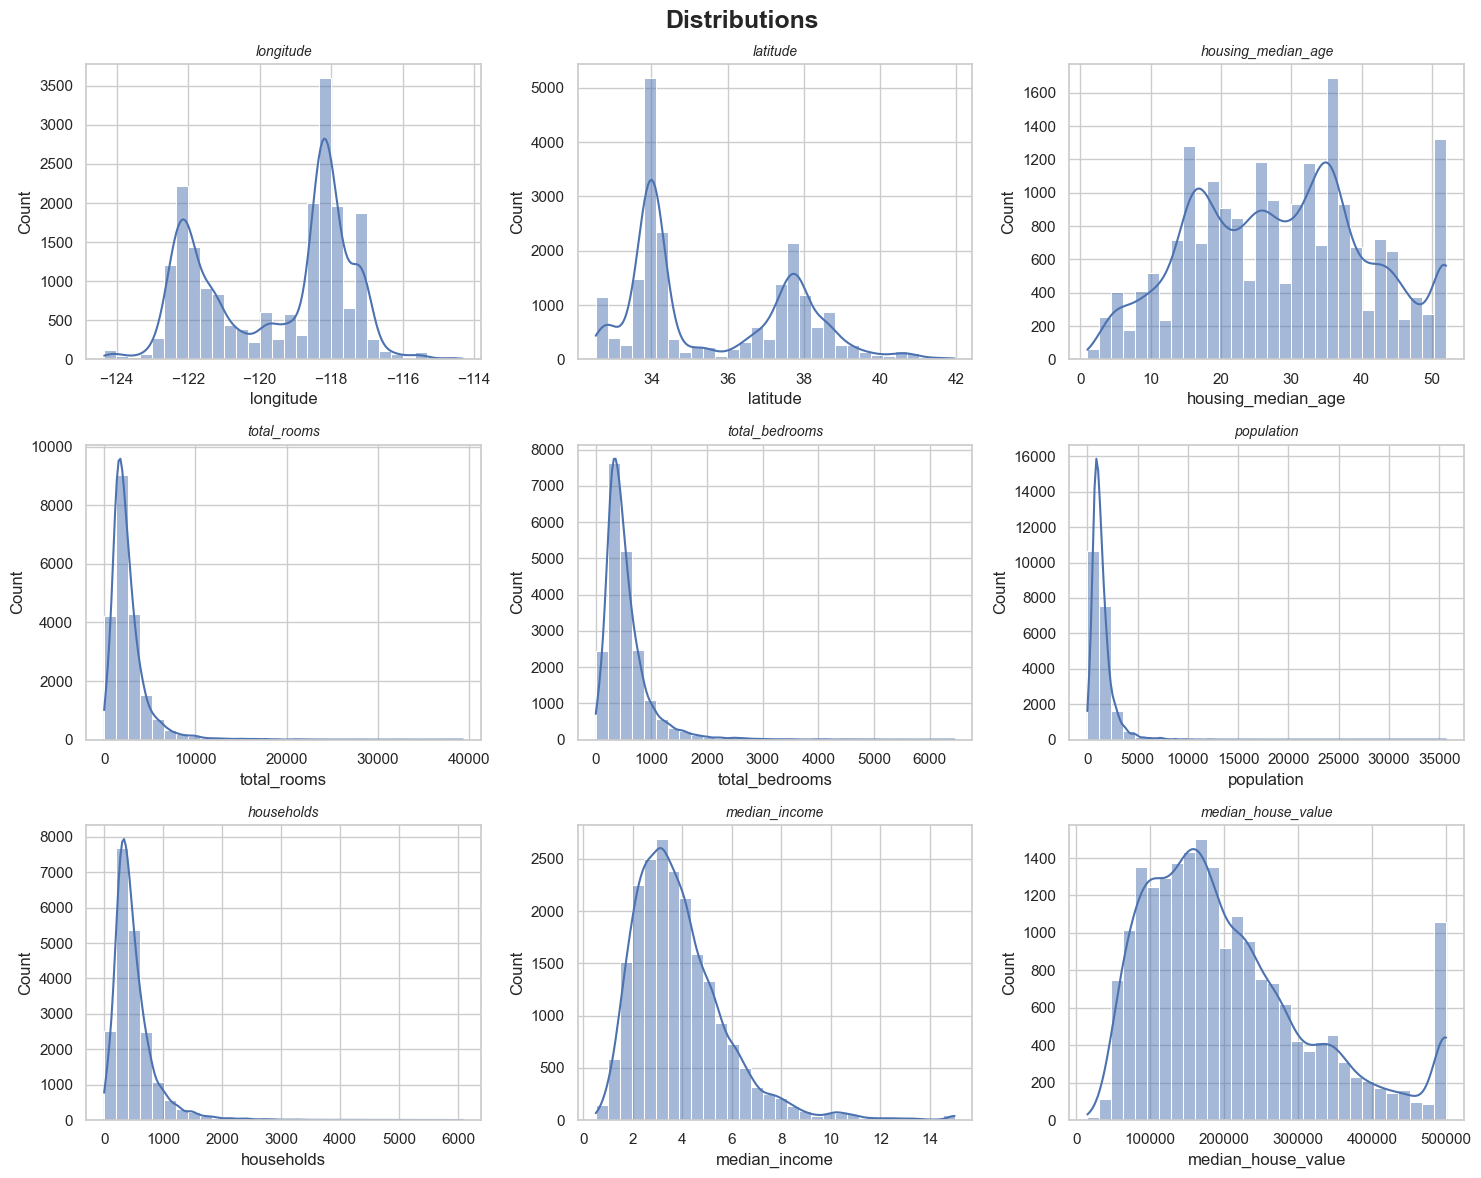

In [57]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'median_house_value']

fig , axes = plt.subplots(nrows = 3, ncols=3 , figsize=(15,12))
fig.suptitle('Distributions', fontsize = 18, fontweight = 'bold')

for i, col in enumerate (columns):
        row = i//3
        col_idx = i%3
        ax = axes[row, col_idx]
        sns.histplot(data = df, x = col, kde = True, ax = ax, bins = 30)
        ax.set_title(col, fontsize = 10, fontstyle = 'italic')

plt.tight_layout()
plt.show()

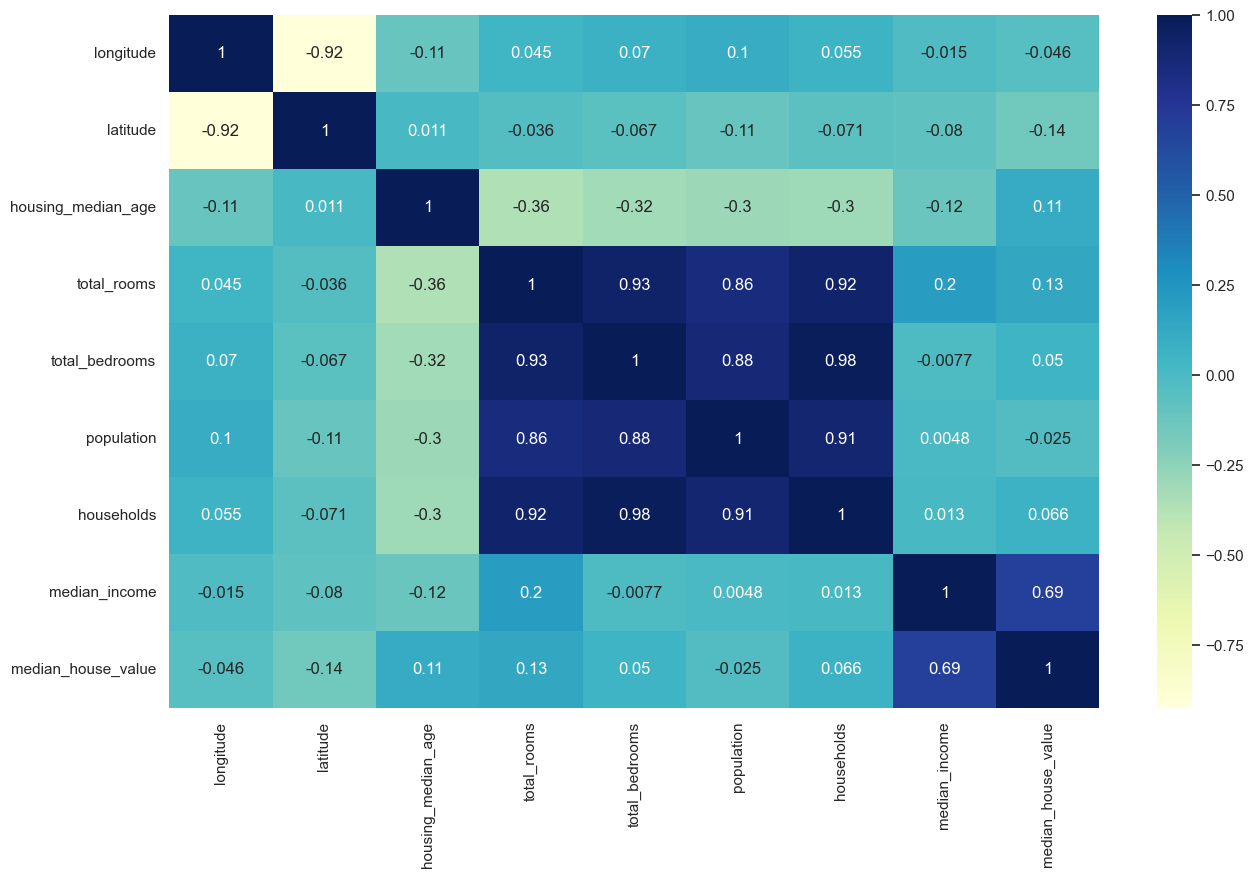

In [58]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.show()

In [59]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}
    numeric_cols = df.select_dtypes(include=['float64','int64']).columns
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - threshold * iqr
        upper_bound = q3 + threshold * iqr

        outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = {
            'outliers_count':outlier.shape[0],
            'outliers_percentage':100 * (outlier.shape[0]/df.shape[0]),
            'lower_bound':lower_bound,
            'upper_bound':upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [60]:
find_outliers_iqr(df, threshold= 1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outliers_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outliers_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [61]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'median_house_value']
for col in columns:
    print(f'Skewness of {col} = {df[col].skew()}')

Skewness of longitude = -0.2978012079524363
Skewness of latitude = 0.4659530037099799
Skewness of housing_median_age = 0.06033063759913685
Skewness of total_rooms = 4.147343450632158
Skewness of total_bedrooms = 3.459546331523342
Skewness of population = 4.935858226727124
Skewness of households = 3.4104377116671474
Skewness of median_income = 1.6466567021344465
Skewness of median_house_value = 0.9777632739098342


In [62]:
# Reduces skewness in right-skewed data
skewed_cols = [
    'total_rooms', 'total_bedrooms',
    'population', 'households',
    'median_income'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

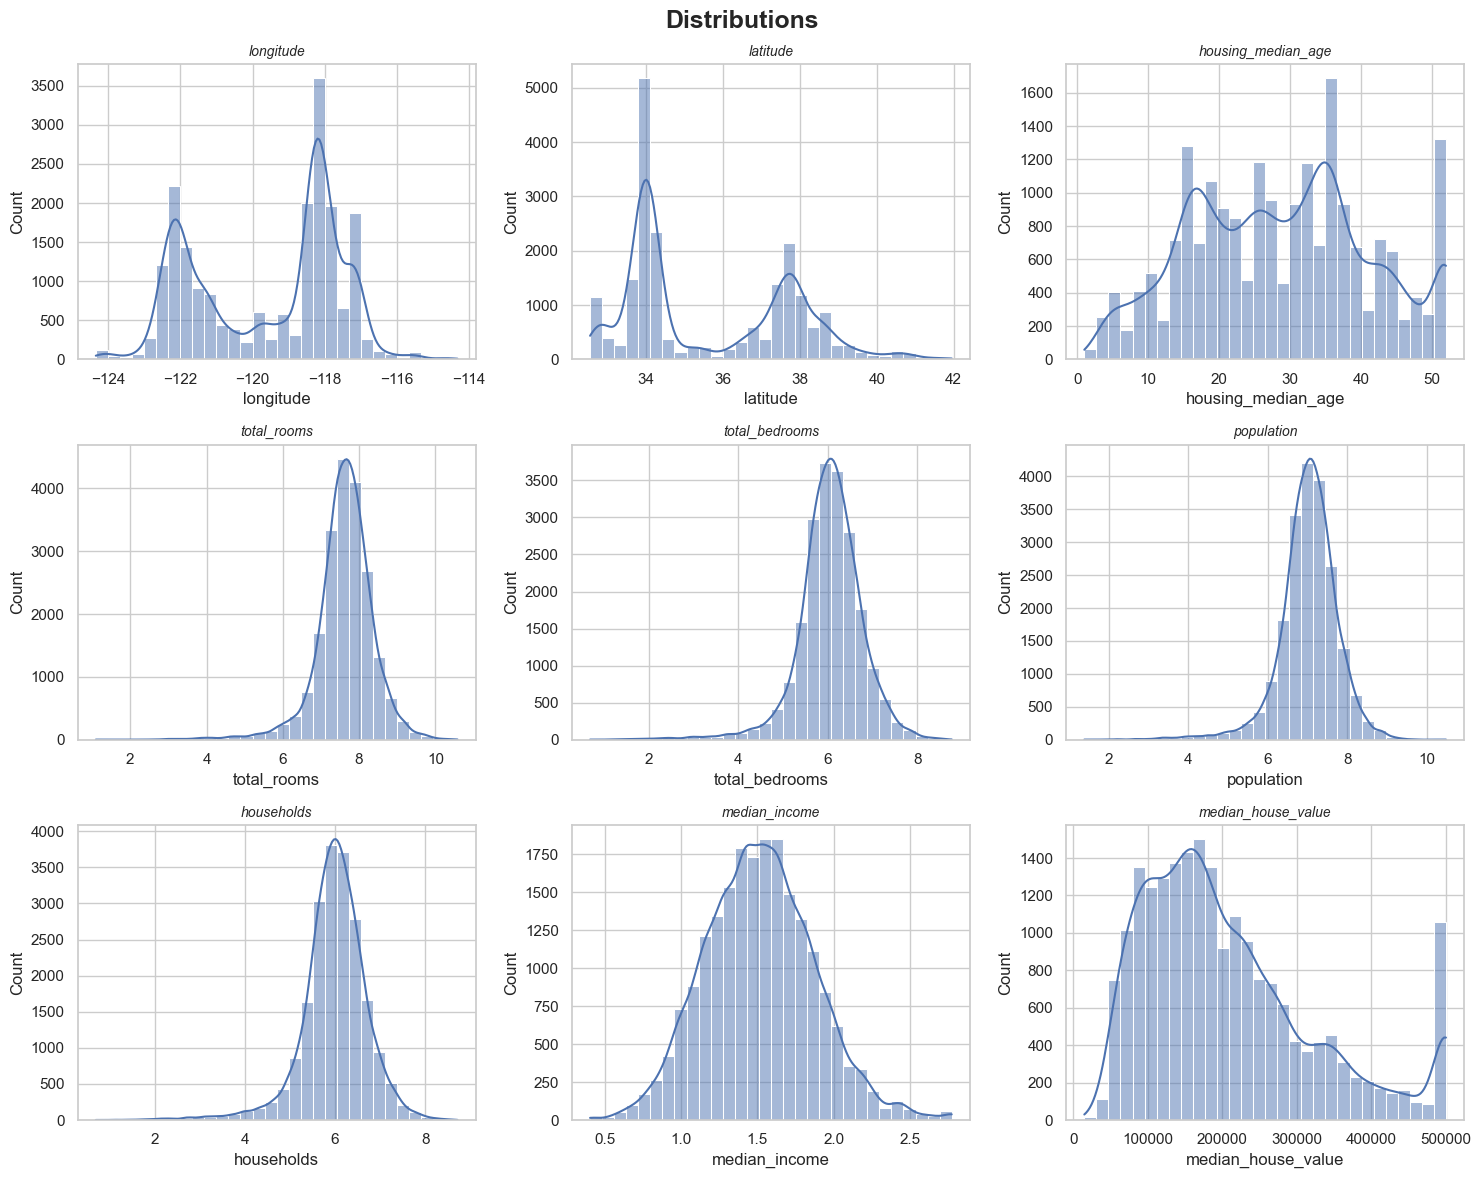

In [63]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'median_house_value']

fig , axes = plt.subplots(nrows = 3, ncols=3 , figsize=(15,12))
fig.suptitle('Distributions', fontsize = 18, fontweight = 'bold')

for i, col in enumerate (columns):
        row = i//3
        col_idx = i%3
        ax = axes[row, col_idx]
        sns.histplot(data = df, x = col, kde = True, ax = ax, bins = 30)
        ax.set_title(col, fontsize = 10, fontstyle = 'italic')

plt.tight_layout()
plt.show()

In [64]:
find_outliers_iqr(df, threshold= 1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outliers_count,0.000,0.00,0.0,957.000000,819.000000,848.000000,882.000000,226.000000,1071.000000
outliers_percentage,0.000,0.00,0.0,4.636628,3.968023,4.108527,4.273256,1.094961,5.188953
lower_bound,-127.485,28.26,-10.5,6.113881,4.523494,5.493402,4.485567,0.554750,-98087.500000
upper_bound,-112.325,43.38,65.5,9.219416,7.644129,8.629658,7.559668,2.463990,482412.500000


In [65]:
def remove_outliers_from_column(df, target_col, threshold=1.5):
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - threshold*iqr
        upper_bound = q3 + threshold*iqr
        return  df[(df[col]>= lower_bound) & (df[col]<=upper_bound)]

In [66]:
print('Original data shape : ', df.shape)
df_model = remove_outliers_from_column(df,'median_house_value')
print('Only median_house_value column cleaning shape : ', df_model.shape)

Original data shape :  (20640, 10)
Only median_house_value column cleaning shape :  (19569, 10)


In [67]:
df_model['total_bedrooms'] = df_model['total_bedrooms'].fillna(df_model['total_bedrooms'].mean())

In [68]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,19569.0,-119.562786,2.005764,-124.350000,-121.760000,-118.510000,-117.990000,-114.310000
latitude,19569.0,35.654159,2.151007,32.540000,33.930000,34.270000,37.730000,41.950000
housing_median_age,19569.0,28.352752,12.497772,1.000000,18.000000,28.000000,37.000000,52.000000
total_rooms,19569.0,7.622885,0.748922,1.098612,7.271704,7.654917,8.046870,10.579514
total_bedrooms,19569.0,6.059746,0.719758,1.098612,5.703782,6.073045,6.470800,8.771215
population,19569.0,7.038543,0.734590,1.386294,6.682109,7.074963,7.467371,10.482430
households,19569.0,5.989492,0.724067,1.098612,5.645447,6.021023,6.408529,8.713253
median_income,19569.0,1.486294,0.329512,0.405398,1.259228,1.490925,1.717772,2.772595
median_house_value,19569.0,190852.301906,95438.555669,14999.000000,116200.000000,173200.000000,246700.000000,482200.000000


In [69]:
df_model["bedroom_ratio"] = df_model["total_bedrooms"] / df_model["total_rooms"]
df_model["household_rooms"] = df_model["total_rooms"] / df_model["households"]

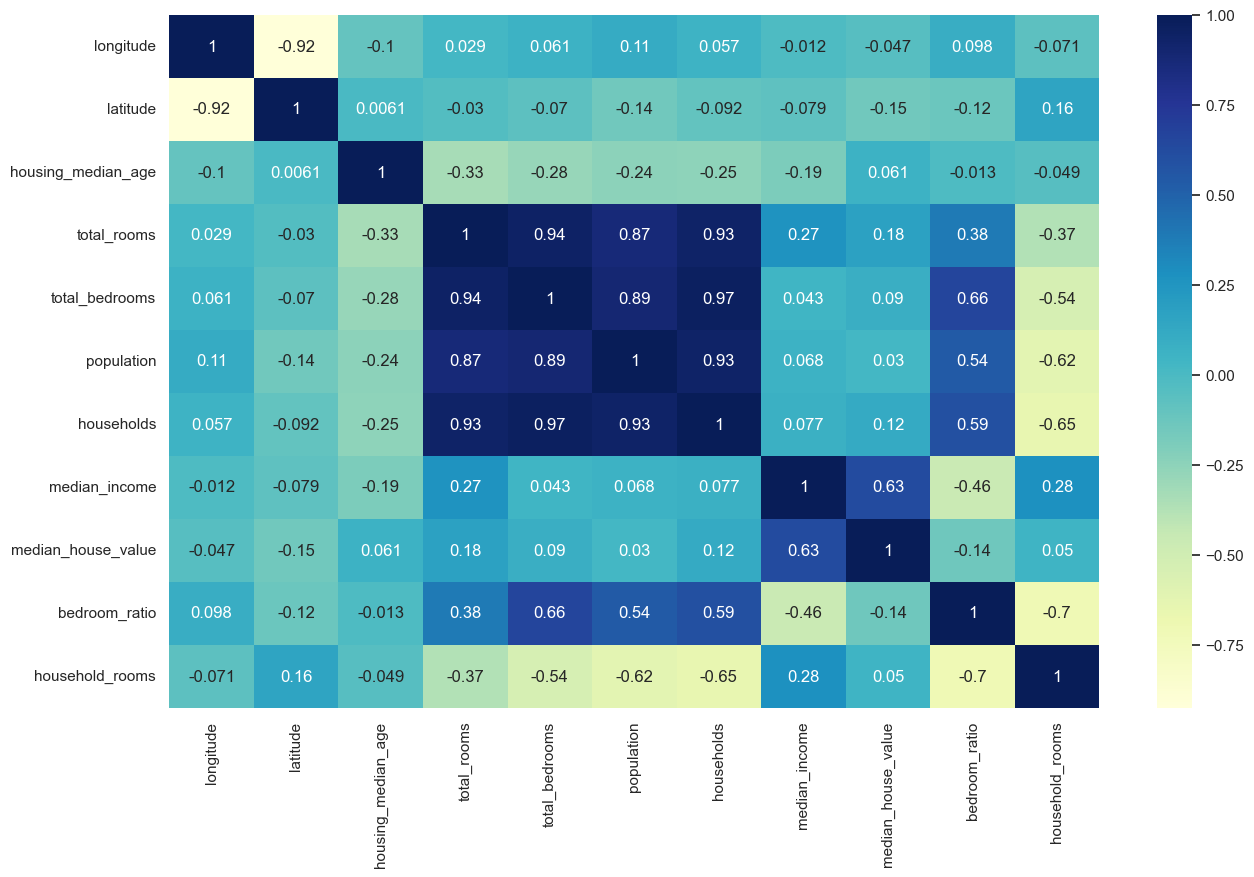

In [70]:
plt.figure(figsize=(15,9))
sns.heatmap(df_model.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.show()

# Training Machine Learning Models

In [71]:
df_model = pd.get_dummies(df_model, columns = ['ocean_proximity'], drop_first = True, dtype=int)

In [72]:
X = df_model.drop('median_house_value', axis=1)
y = df_model['median_house_value']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [81]:
models = {
    'linearRegressin' : LinearRegression(),
    'Ridge': Ridge(),
    'Lasso' : Lasso(),
    'Xgboost' : XGBRegressor(),
    'DecisionTree' : DecisionTreeRegressor(),
    'RandomForest' : RandomForestRegressor(),
    'lightgbm' : LGBMRegressor(),
}

In [82]:
results = []
print(f"\n{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 61)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)

    results.append({
        'Model': name, 
        'MAE': round(mae,4),
        'RMSE': round(rmse,4), 
        'R²': round(r2,4)})
    print(f"{name:<30} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}")

df_results = pd.DataFrame(results).sort_values('R²', ascending=False)
df_results


Model                               MAE     RMSE       R²
-------------------------------------------------------------
linearRegressin                44672.1752 59300.9580   0.6219
Ridge                          44675.5743 59308.6692   0.6218
Lasso                          44671.6138 59303.0123   0.6219
Xgboost                        28107.7800 41951.0912   0.8108
DecisionTree                   42149.6428 62653.7277   0.5779
RandomForest                   29683.3854 44259.2969   0.7894
lightgbm                       28746.0401 42421.3648   0.8065


,Model,MAE,RMSE,R²
3,Xgboost,28107.7800,41951.0912,0.8108
6,lightgbm,28746.0401,42421.3648,0.8065
5,RandomForest,29683.3854,44259.2969,0.7894
0,linearRegressin,44672.1752,59300.9580,0.6219
2,Lasso,44671.6138,59303.0123,0.6219
1,Ridge,44675.5743,59308.6692,0.6218
4,DecisionTree,42149.6428,62653.7277,0.5779


# Hyperparameter Tuning of XGBoost

In [89]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [84]:
params = {
    "n_estimators": [100, 150, 200],         
    "max_depth": [3, 4, 5],                 
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "gamma": [0, 0.1]
}

In [85]:
gsc = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [86]:
gsc.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [87]:
gsc.best_params_

{'colsample_bytree': 1.0,
 'gamma': 0,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 200,
 'subsample': 1.0}

In [88]:
model_gsc = XGBRegressor(**gsc.best_params_)
model_gsc.fit(X_train, y_train, verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [98]:
y_test_pred = model_gsc.predict(X_test)

test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

print("Xgboost")
print('model performance for Test Set')
print('Root mean squared error: ',test_rmse)
print('Mean absolute error: ',test_mae)
print('R2 score: ',test_r2)

Xgboost
model performance for Test Set
Root mean squared error:  41849.35303316741
Mean absolute error:  28290.120638652912
R2 score:  0.8116912702699709


# Exporting The Model

In [99]:
pickle.dump(model_gsc, open('House_price_predictor.pkl', 'wb'))

# Neural Networks

In [137]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [138]:
model = Sequential([
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

In [139]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [140]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 44882845696.0000 - mae: 189300.3125 - val_loss: 42718892032.0000 - val_mae: 184456.5469
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 29621329920.0000 - mae: 146395.1094 - val_loss: 14390057984.0000 - val_mae: 94978.8906
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 9956026368.0000 - mae: 75601.5859 - val_loss: 7779836416.0000 - val_mae: 64805.4375
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6578348032.0000 - mae: 60530.8398 - val_loss: 5968861184.0000 - val_mae: 56848.5859
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5238598656.0000 - mae: 54101.1758 - val_loss: 5054335488.0000 - val_mae: 52502.0703
Epoch 6/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 4549562880.0000 - mae: 50427.6016 - val_loss: 4531032576.0000 - val_mae: 49916.0156
Epoch 7/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 4148402176.0000 - mae: 48130.8906 - val_loss: 4196221952.

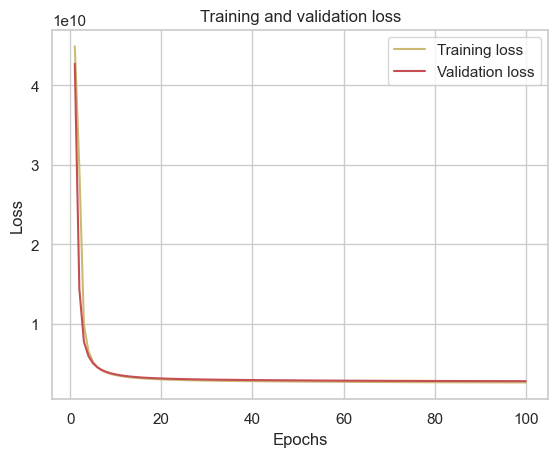

In [142]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

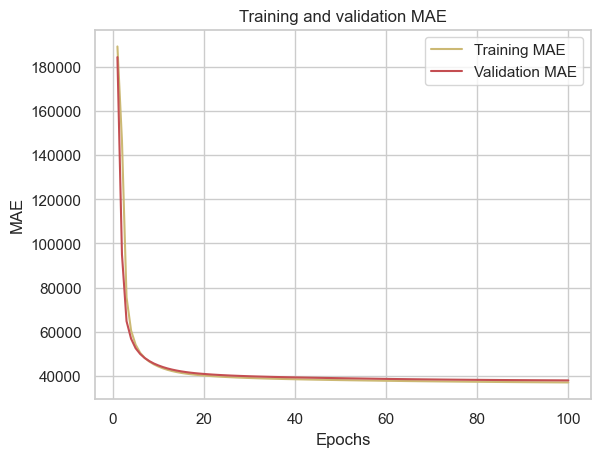

In [143]:
acc = history.history['mae']
val_acc = history.history['val_mae']
plt.plot(epochs, acc, 'y', label='Training MAE')
plt.plot(epochs, val_acc, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [144]:
mse_neural, mae_neural = model.evaluate(X_test_scaled, y_test)
print('Mean squared error from neural net: ', mse_neural)
print('Mean absolute error from neural net: ', mae_neural)

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2678706176.0000 - mae: 36953.3086
Mean squared error from neural net:  2678706176.0
Mean absolute error from neural net:  36953.30859375


In [145]:
y_test_pred = model.predict(X_test_scaled)
test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

print('model performance for Test Set')
print('Mean squared error: ',test_rmse)
print('Mean absolute error: ',test_mae)
print('R2 score: ',test_r2)

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
model performance for Test Set
Mean squared error:  51756.21958065533
Mean absolute error:  36953.314153719024
R2 score:  0.711983047804831
